# Tutorial - Extract Gait Features

In [12]:
import sys
import pandas as pd
from typing import Dict, List
from pathlib import Path

project_root = Path.cwd().parent

# Add the project root to the Python path
sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")

Project root: /Users/pmui/dev/alex/alexpose


## 1.  Load GAVD Gait Sequence

In [13]:
from ambient.gavd import GaitDataProcessor, GAVDDataLoader, PoseDataConverter
from ambient.pose.pose_estimators import OpenPoseEstimator
from ambient.utils.csv_parser import parse_csv_with_dicts

In [14]:
gavd_loader = GAVDDataLoader()
df = gavd_loader.load_gavd_data(Path(project_root, "data", "GAVD_Clinical_Annotations_1.3.csv"))
sequences = gavd_loader.organize_by_sequence(df)
len(sequences)

2026-01-18 10:16:35.689 | INFO     | ambient.gavd.gavd_processor:load_gavd_data:347 - Loading GAVD data from: /Users/pmui/dev/alex/alexpose/data/GAVD_Clinical_Annotations_1.3.csv
2026-01-18 10:16:35.700 | WARNING  | ambient.gavd.gavd_processor:_download_youtube_videos:292 - YouTube cookies file not found at /Users/pmui/dev/alex/alexpose/config/yt_cookies.txt
2026-01-18 10:16:35.702 | INFO     | ambient.utils.youtube_cache:_prepare_download_list:227 - Already cached (skipping): /Users/pmui/dev/alex/alexpose/data/youtube/TgkxrrhnvlM.mp4
2026-01-18 10:16:35.706 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:304 - YouTube cache attempted: 1
2026-01-18 10:16:35.707 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:305 - YouTube cache skipped: 1
2026-01-18 10:16:35.708 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:306 - YouTube cache downloaded: 0
2026-01-18 10:16:35.709 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:3

1

## 2. Describe Sequence

In [15]:
type(sequences), sequences.keys()

(dict, dict_keys(['cljaoak47000i3n6lsrb9rit9']))

In [16]:
sequences

{'cljaoak47000i3n6lsrb9rit9':                            seq  frame_num   cam_view             gait_event  \
 0    cljaoak47000i3n6lsrb9rit9        205  left side                          
 1    cljaoak47000i3n6lsrb9rit9        206  left side                          
 2    cljaoak47000i3n6lsrb9rit9        207  left side                          
 3    cljaoak47000i3n6lsrb9rit9        208  left side                          
 4    cljaoak47000i3n6lsrb9rit9        209  left side  Right initial contact   
 ..                         ...        ...        ...                    ...   
 146  cljaoak47000i3n6lsrb9rit9        351  left side                          
 147  cljaoak47000i3n6lsrb9rit9        352  left side                          
 148  cljaoak47000i3n6lsrb9rit9        353  left side                          
 149  cljaoak47000i3n6lsrb9rit9        354  left side                          
 150  cljaoak47000i3n6lsrb9rit9        355  left side                          
 
         

In [18]:
sequence_id = list(sequences.keys())[0]
sequence_id

'cljaoak47000i3n6lsrb9rit9'

In [19]:
sequence_data = sequences[sequence_id]
sequence_data

,seq,frame_num,cam_view,gait_event,dataset,gait_pat,bbox,vid_info,id,url,_processed_at,_source_file
0,cljaoak47000i3n6lsrb9rit9,205,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 399.0, 'height': 678.0, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
1,cljaoak47000i3n6lsrb9rit9,206,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 380.6666666666667, 'heigh...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
2,cljaoak47000i3n6lsrb9rit9,207,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 362.3333333333333, 'heigh...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
3,cljaoak47000i3n6lsrb9rit9,208,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 344.0, 'height': 718.0, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
4,cljaoak47000i3n6lsrb9rit9,209,left side,Right initial contact,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 344.4, 'height': 718.4, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...
146,cljaoak47000i3n6lsrb9rit9,351,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 336.0, 'height': 717.0, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
147,cljaoak47000i3n6lsrb9rit9,352,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 351.75, 'height': 707.25,...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
148,cljaoak47000i3n6lsrb9rit9,353,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 367.5, 'height': 697.5, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
149,cljaoak47000i3n6lsrb9rit9,354,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 383.25, 'height': 687.75,...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown


In [20]:
type(sequence_data)

pandas.core.frame.DataFrame

In [21]:
sequence_data.shape

(151, 12)

In [22]:
sequence_data.head(3)

,seq,frame_num,cam_view,gait_event,dataset,gait_pat,bbox,vid_info,id,url,_processed_at,_source_file
0,cljaoak47000i3n6lsrb9rit9,205,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 399.0, 'height': 678.0, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
1,cljaoak47000i3n6lsrb9rit9,206,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 380.6666666666667, 'heigh...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown
2,cljaoak47000i3n6lsrb9rit9,207,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 362.3333333333333, 'heigh...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-18 10:16:35.716464,unknown


## 3. Visualize Frames

Scaled bbox: annotation=1280x720, video=640x360, scale=(0.500, 0.500)
Bbox drawn: left=199, top=0, width=167, height=339


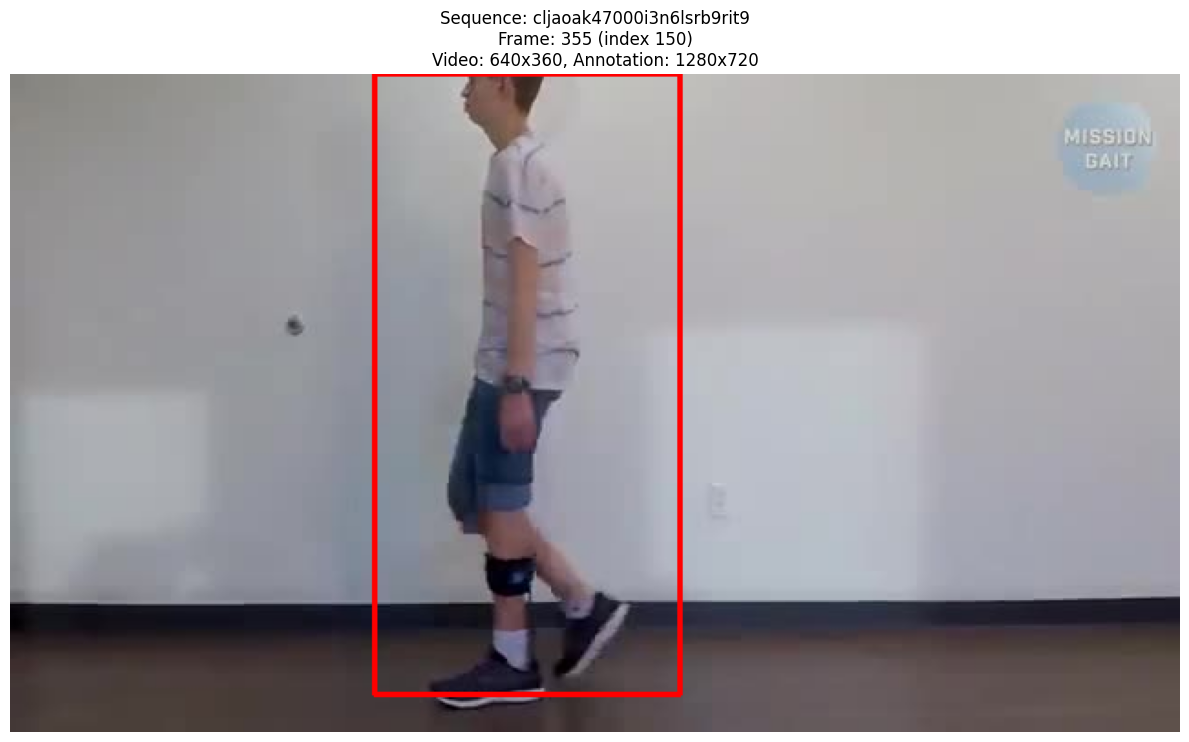

Displayed frame 355 from sequence cljaoak47000i3n6lsrb9rit9


In [24]:
from ambient.utils.viz import visualize_frame

visualize_frame(project_root=project_root, sequences=sequences, seq_id=sequence_id, frame_index=150, show_bbox=True)

## 4. Pose Estimation using MediaPipe

In [25]:
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.utils.eval_keypoints import get_gavd_frame, visualize_keypoints

video_base_path = project_root / "data" / "youtube"

extractor = SequenceKeypointExtractor()
keypoints_array = extractor.extract_from_sequence(
    sequence_data,
    video_base_path
)

len(keypoints_array)

2026-01-18 10:24:08.292 | DEBUG    | ambient.pose.mediapipe_singleton:reset_landmarker:129 - Force resetting landmarker
2026-01-18 10:24:08.387 | DEBUG    | ambient.pose.mediapipe_singleton:_cleanup_landmarker:149 - Landmarker cleaned up successfully
2026-01-18 10:24:08.388 | DEBUG    | ambient.pose.mediapipe_singleton:get_landmarker:80 - Creating new landmarker: initial creation
I0000 00:00:1768760648.392631 3314108 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1768760648.444970 3314109 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768760648.456925 3314109 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-18 10:24:08.457 | DEBUG    | ambient.pose.mediapipe_singleton:get_landmarker:95 - New landmarker created successfully
2026-01-18 

[OK] Pose Landmarker created from /Users/pmui/dev/alex/alexpose/notebooks/data/models/pose_landmarker_full.task


2026-01-18 10:24:10.086 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 215 (11/151)
2026-01-18 10:24:11.674 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 225 (21/151)
2026-01-18 10:24:13.280 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 235 (31/151)
2026-01-18 10:24:14.872 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 245 (41/151)
2026-01-18 10:24:16.473 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 255 (51/151)
2026-01-18 10:24:18.116 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 265 (61/151)
2026-01-18 10:24:19.729 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing frame 275 (71/151)
2026-01-18 10:24:21.362 | DEBUG    | ambient.pose.keypoint_extractor:extract_from_sequence:606 - Processing fra

151

In [28]:
type(keypoints_array[0].keypoints)

list

In [29]:
len(keypoints_array[0].keypoints)

33

In [31]:
keypoints_array[0].keypoints[32]

Keypoint(id=32, name='RIGHT_FOOT_INDEX', x=223.8436508178711, y=300.68185329437256, z=0.13918471336364746, confidence=0.9572378993034363, visibility=0.9572378993034363, presence=0.9994938373565674, x_normalized=0.3497557044029236, y_normalized=0.835227370262146)

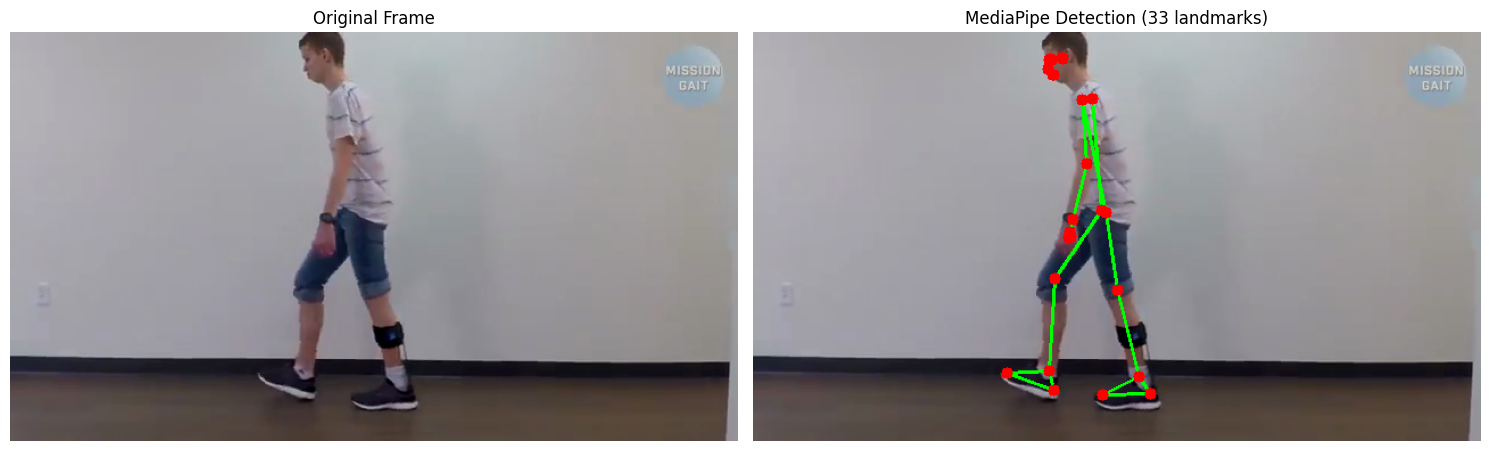

[OK] SUCCESS! Detected 33 landmarks
[INFO] 28 landmarks are visible (confidence > 0.5)
[INFO] Average confidence: 0.851
[INFO] Detection quality: 0.901

[INFO] Sample keypoints:
  NOSE: (259.3, 33.8) confidence=1.000
  LEFT_EYE_INNER: (261.2, 25.9) confidence=1.000
  LEFT_EYE: (262.0, 25.6) confidence=1.000
  LEFT_EYE_OUTER: (262.9, 25.1) confidence=1.000
  RIGHT_EYE_INNER: (260.6, 25.9) confidence=1.000


In [32]:
first_frame = get_gavd_frame(
    sequence_data=sequence_data,
    frame_num=0,
    video_base_path=video_base_path
)
visualize_keypoints(keypoints_array[0], first_frame)

## 5. Calculate Joint Angles 

In [36]:
from ambient.pose.joint_angles import get_joint_angles

joint_angles = get_joint_angles(
    keypoints_array=keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3
)

2026-01-18 11:30:38.448 | INFO     | ambient.pose.joint_angles:__init__:231 - JointAngleCalculator initialized for BLAZEPOSE_33 format
2026-01-18 11:30:38.460 | INFO     | ambient.pose.joint_angles:calculate_sequence_angles:480 - Calculated joint angles for 151 frames (BLAZEPOSE_33 format)


In [40]:
joint_angles.to_dict()

{'sequence_id': None,
 'keypoint_format': 'BLAZEPOSE_33',
 'fps': 30.0,
 'num_frames': 151,
 'frames': [{'frame_index': 0,
   'timestamp': 6.83,
   'keypoint_format': 'BLAZEPOSE_33',
   'angles': {'left_hip': {'angle_degrees': 176.51,
     'confidence': 1.0,
     'landmark_indices': (11, 23, 25)},
    'left_knee': {'angle_degrees': 174.41,
     'confidence': 0.99,
     'landmark_indices': (23, 25, 27)},
    'right_hip': {'angle_degrees': 141.27,
     'confidence': 0.97,
     'landmark_indices': (12, 24, 26)},
    'right_knee': {'angle_degrees': 150.23,
     'confidence': 0.95,
     'landmark_indices': (24, 26, 28)},
    'left_ankle': {'angle_degrees': 101.68,
     'confidence': 0.99,
     'landmark_indices': (25, 27, 31)},
    'right_ankle': {'angle_degrees': 97.11,
     'confidence': 0.94,
     'landmark_indices': (26, 28, 32)}}},
  {'frame_index': 1,
   'timestamp': 6.87,
   'keypoint_format': 'BLAZEPOSE_33',
   'angles': {'left_hip': {'angle_degrees': 160.52,
     'confidence': 0.99

In [41]:
joint_angles.get_statistics(joint_name="left_hip")

{'mean': 161.37947967306275,
 'std': 11.831166597263875,
 'min': 136.21562975558163,
 'max': 179.97606590578772,
 'range': 43.76043615020609,
 'valid_count': 151}